# Reporte de ejercicios — Modelos probabilísticos

**Diplomado en Técnicas Estadísticas y Minería de Datos — Unidad 2**

**Autor:** yagoraulhuertaorozco@gmail.com

**Fecha:** 29 de septiembre de 2026

---


<a id="introduccion"></a>
## 1. Introducción

Este cuaderno resuelve los ejercicios de modelos probabilísticos del archivo `05_Ejercicios_modelos_probabilisticos.pdf`. Se trabajan cuatro problemas:

- **Ejercicio 2.1**: aplicación del Teorema de Bayes al diagnóstico médico (probabilidad condicional con sensibilidad, especificidad y prevalencia).
- **Ejercicio 2.2**: aplicación del Teorema de Bayes a un sistema de detección de fraudes en pagos electrónicos.
- **Ejercicio 2.3**: ajuste de una distribución binomial negativa al conteo diario de infracciones de tránsito en el condado de Montgomery, MD (dataset `Traffic_Violations.csv`).
- **Ejercicio 2.4**: ajuste de distribuciones normales univariadas y multivariadas a variables fisiológicas (temperatura corporal y frecuencia cardíaca) del dataset `thermometry.csv` de OpenIntro.

Se utiliza `sympy` para las derivaciones simbólicas, `scipy.stats` para los ajustes y probabilidades teóricas, y `pandas` + `matplotlib` para el análisis descriptivo y las visualizaciones.


<a id="indice"></a>
## 2. Índice

- [1. Introducción](#introduccion)
- [2. Índice](#indice)
- [3. Configuración inicial](#setup)
- [4. Ejercicio 2.1 — Pruebas médicas (Bayes)](#ej21)
- [5. Ejercicio 2.2 — Detección de fraude (Bayes)](#ej22)
- [6. Ejercicio 2.3 — Infracciones de tránsito (Binomial Negativa)](#ej23)
- [7. Ejercicio 2.4 — Temperatura y frecuencia cardíaca (Normal)](#ej24)
- [8. Conclusiones](#conclusiones)


<a id="setup"></a>
## 3. Configuración inicial


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sympy as sp
from scipy import optimize, stats

SEED = 20260929
np.random.seed(SEED)

sp.init_printing(use_latex='mathjax')

sns.set_theme(style='whitegrid', rc={
    'figure.facecolor': '#fcfcfb',
    'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': '#0b0b0b',
    'grid.color': '#e1e0d9',
    'text.color': '#0b0b0b',
    'xtick.color': '#52514e',
    'ytick.color': '#52514e',
    'font.family': 'sans-serif',
})

PALETTE_CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']
COLOR_HIGHLIGHT = '#e34948'
COLOR_MEAN = '#e34948'
COLOR_THEORETICAL = PALETTE_CATEGORICAL[1]
COLOR_EMPIRICAL = PALETTE_CATEGORICAL[0]

DATA_DIR = Path('/home/yagoh/Escritorio/Personal/dev/Educacion/'
                'Diplomado-Tecnicas-Estadisticas-y-Mineria-de-Datos/'
                'Unidad_2/Data')

print(f'Data dir: {DATA_DIR}')
print(f'Semilla aleatoria: {SEED}')


Data dir: /home/yagoh/Escritorio/Personal/dev/Educacion/Diplomado-Tecnicas-Estadisticas-y-Mineria-de-Datos/Unidad_2/Data
Semilla aleatoria: 20260929


<a id="ej21"></a>
## 4. Ejercicio 2.1 — Pruebas médicas (Bayes)

Una prueba diagnóstica presenta las siguientes características:

| Parámetro | Símbolo | Valor |
|-----------|---------|-------|
| Sensibilidad | $S_e$ | $0.95$ |
| Especificidad | $S_p$ | $0.90$ |
| Prevalencia | $P$ | $0.01$ |

La tabla de contingencia entre el estado real de la enfermedad y el resultado de la prueba es:

|                  | Enfermo ($P$)             | No enfermo ($1-P$)       | Total            |
|------------------|---------------------------|--------------------------|------------------|
| Prueba positiva  | $V_P = S_e \cdot P$      | $F_P = (1-S_p)(1-P)$     | $V_P + F_P$      |
| Prueba negativa  | $F_N = (1-S_e) P$        | $V_N = S_p (1-P)$        | $F_N + V_N$      |
| **Total**        | $P$                       | $1-P$                    | $1$              |

Se desea calcular la **probabilidad de que una persona con prueba positiva esté realmente enferma**, es decir $P(\text{Enfermo} \mid +)$.


In [2]:
# Valores nominales del problema
Se = 0.95   # sensibilidad
Sp = 0.90   # especificidad
P  = 0.01   # prevalencia

vp = Se * P                  # Verdaderos positivos
fn = (1 - Se) * P            # Falsos negativos
fp = (1 - Sp) * (1 - P)      # Falsos positivos
vn = Sp * (1 - P)            # Verdaderos negativos

print(f"{' ':18s}{'Enfermo':>12s}{'Sano':>12s}{'Total':>12s}")
print(f"{'Prueba +':18s}{vp:>12.5f}{fp:>12.5f}{vp+fp:>12.5f}")
print(f"{'Prueba -':18s}{fn:>12.5f}{vn:>12.5f}{fn+vn:>12.5f}")
print(f"{'Total':18s}{P:>12.5f}{1-P:>12.5f}{1.0:>12.5f}")


                       Enfermo        Sano       Total
Prueba +               0.00950     0.09900     0.10850
Prueba -               0.00050     0.89100     0.89150
Total                  0.01000     0.99000     1.00000


Aplicando el Teorema de Bayes:

$$
P(\text{Enfermo} \mid +) = \frac{P(+ \mid \text{Enfermo}) \, P(\text{Enfermo})}{P(+)} = \frac{S_e \cdot P}{S_e \cdot P + (1 - S_p)(1 - P)}
$$

Verificamos simbólicamente con `sympy`:


In [3]:
# Verificación simbólica con sympy
Se_s, Sp_s, P_s = sp.symbols('Se Sp P', positive=True)

vp_s = Se_s * P_s
fp_s = (1 - Sp_s) * (1 - P_s)
p_pos_s = vp_s + fp_s

p_enf_dado_pos = sp.simplify(vp_s / p_pos_s)
print('P(Enfermo|+) =', p_enf_dado_pos)

p_sano_dado_pos = sp.simplify(fp_s / p_pos_s)
print('P(Sano|+)     =', p_sano_dado_pos)
print('Suma          =', sp.simplify(p_enf_dado_pos + p_sano_dado_pos))


P(Enfermo|+) = P*Se/(P*Se + (P - 1)*(Sp - 1))
P(Sano|+)     = (P - 1)*(Sp - 1)/(P*Se + (P - 1)*(Sp - 1))
Suma          = 1


In [4]:
# Cálculo numérico
p_enf_pos = vp / (vp + fp)
p_sano_pos = fp / (vp + fp)

print(f"P(Enfermo|+) = {p_enf_pos:.6f}  ({p_enf_pos*100:.2f} %)")
print(f"P(Sano|+)     = {p_sano_pos:.6f}  ({p_sano_pos*100:.2f} %)")


P(Enfermo|+) = 0.087558  (8.76 %)
P(Sano|+)     = 0.912442  (91.24 %)


**Conclusión 2.1.** A pesar de que la prueba tiene una sensibilidad del 95 % y una especificidad del 90 %, la probabilidad de estar realmente enfermo tras un resultado positivo es de apenas el $8.76\,\%$. Este fenómeno, conocido como la **paradoja de Base Rate** (o de la baja prevalencia), ocurre porque la condición es rara en la población ($P = 0.01$): el número absoluto de falsos positivos $(F_P \approx 0.099)$ supera al de verdaderos positivos $(V_P = 0.0095)$, haciendo que la mayoría de las alertas positivas correspondan a personas sanas.

[Volver al índice](#indice)


<a id="ej22"></a>
## 5. Ejercicio 2.2 — Detección de fraude (Bayes)

Un sistema automático de detección de fraude en pagos electrónicos presenta:

| Parámetro | Símbolo | Valor |
|-----------|---------|-------|
| Probabilidad de fraude | $P(F)$ | $0.02$ |
| Sensibilidad | $S_e$ | $0.98$ |
| Especificidad | $S_p$ | $0.95$ |

Se pide la probabilidad de que una alerta de fraude sea verdadera: $P(F \mid \text{alerta})$.


In [5]:
P_fraude = 0.02
Se_f = 0.98
Sp_f = 0.95

vp_f = Se_f * P_fraude               # Verdaderos positivos (fraudes reales)
fp_f = (1 - Sp_f) * (1 - P_fraude)   # Falsos positivos (transacciones legitimas)
fn_f = (1 - Se_f) * P_fraude         # Falsos negativos (fraudes no detectados)
vn_f = Sp_f * (1 - P_fraude)         # Verdaderos negativos

print(f"{' ':18s}{'Fraude':>12s}{'Legitima':>12s}{'Total':>12s}")
print(f"{'Alerta':18s}{vp_f:>12.5f}{fp_f:>12.5f}{vp_f+fp_f:>12.5f}")
print(f"{'Sin alerta':18s}{fn_f:>12.5f}{vn_f:>12.5f}{fn_f+vn_f:>12.5f}")
print(f"{'Total':18s}{P_fraude:>12.5f}{1-P_fraude:>12.5f}{1.0:>12.5f}")


                        Fraude    Legitima       Total
Alerta                 0.01960     0.04900     0.06860
Sin alerta             0.00040     0.93100     0.93140
Total                  0.02000     0.98000     1.00000


Por el Teorema de Bayes:

$$
P(F \mid \text{alerta}) = \frac{S_e \cdot P(F)}{S_e \cdot P(F) + (1 - S_p)(1 - P(F))}.
$$


In [6]:
p_fraude_alerta = vp_f / (vp_f + fp_f)
p_legitima_alerta = fp_f / (vp_f + fp_f)

print(f"P(Fraude | alerta)     = {p_fraude_alerta:.6f}  ({p_fraude_alerta*100:.2f} %)")
print(f"P(Legítima | alerta)   = {p_legitima_alerta:.6f}  ({p_legitima_alerta*100:.2f} %)")
print()
print(f"Fracción de alertas que son fraude real: {vp_f:.5f} de {vp_f+fp_f:.5f}")
print(f"Fracción de alertas que son falsos positivos: {fp_f:.5f} de {vp_f+fp_f:.5f}")


P(Fraude | alerta)     = 0.285714  (28.57 %)
P(Legítima | alerta)   = 0.714286  (71.43 %)

Fracción de alertas que son fraude real: 0.01960 de 0.06860
Fracción de alertas que son falsos positivos: 0.04900 de 0.06860


**Conclusión 2.2.** Aunque la sensibilidad del detector es muy alta (98 %), solamente el $28.57\,\%$ de las alertas corresponde a fraudes reales. Esto refleja nuevamente el efecto de la baja tasa base: con una prevalencia del 2 % y una especificidad del 95 %, el sistema genera más falsos positivos que detecciones verdaderas en términos absolutos. La consecuencia operacional es que las alertas deben ser **verificadas** por un analista humano antes de bloquear transacciones, para mantener una tasa de falsos positivos manejable.

[Volver al índice](#indice)


<a id="ej23"></a>
## 6. Ejercicio 2.3 — Infracciones de tránsito (Binomial Negativa)

El dataset `Traffic_Violations.csv` (descargado de catalog.data.gov) contiene todas las infracciones de tránsito registradas electrónicamente en el condado de Montgomery, Maryland. Se desea:

1. Contar el número de infracciones por día.
2. Ajustar una distribución de probabilidad al conteo diario.
3. Calcular tres probabilidades específicas sobre ese ajuste.
4. Comparar el histograma empírico con la distribución propuesta.

Se cargan **todas** las columnas del CSV para detectar duplicados exactos antes de agrupar.


In [7]:
ruta_csv = DATA_DIR / 'Traffic_Violations.csv'
print(f'Cargando {ruta_csv.name} ...')
df_raw = pd.read_csv(ruta_csv, low_memory=False)
print(f'Filas crudas: {len(df_raw):,}')
print(f'Columnas ({len(df_raw.columns)}): {list(df_raw.columns)[:6]} ...')

# Eliminar duplicados exactos (errores del sistema)
n_dups = df_raw.duplicated().sum()
df = df_raw.drop_duplicates()
print(f'\nDuplicados exactos eliminados: {n_dups:,}')
print(f'Filas limpias: {len(df):,}')

# Parsear fecha
df['Date Of Stop'] = pd.to_datetime(df['Date Of Stop'], format='%m/%d/%Y', errors='coerce')
df = df.dropna(subset=['Date Of Stop'])
print(f'Fechas validas: {len(df):,}')

# Conteo por dia
conteo_diario = df.groupby('Date Of Stop').size()
conteo_diario.name = 'infracciones'
print(f'Dias unicos: {len(conteo_diario):,}')
print(f'Rango: {conteo_diario.index.min().date()} a {conteo_diario.index.max().date()}')


Cargando Traffic_Violations.csv ...


Filas crudas: 2,020,163
Columnas (43): ['SeqID', 'Date Of Stop', 'Time Of Stop', 'Agency', 'SubAgency', 'Description'] ...



Duplicados exactos eliminados: 2,334
Filas limpias: 2,017,829
Fechas validas: 2,017,829
Dias unicos: 4,922
Rango: 2012-01-01 a 2025-06-24


### 6.1 Análisis descriptivo

La variable de interés es $X =$ número de infracciones en un día. Antes de proponer un modelo, calculamos sus estadísticos principales.


In [8]:
media = conteo_diario.mean()
varianza = conteo_diario.var(ddof=1)
desviacion = conteo_diario.std(ddof=1)
coef_var = desviacion / media
vmr = varianza / media

print('Estadisticos del conteo diario de infracciones')
print('-' * 50)
print(f'n (dias)      = {len(conteo_diario):,}')
print(f'min           = {conteo_diario.min():.0f}')
print(f'max           = {conteo_diario.max():.0f}')
print(f'media (mu)    = {media:.4f}')
print(f'varianza (s2) = {varianza:.4f}')
print(f'desviacion (s)= {desviacion:.4f}')
print(f'coef. var.    = {coef_var:.4f}')
print(f'VMR (s2/mu)   = {vmr:.4f}')
print()
print(f'Cuartiles: Q1 = {conteo_diario.quantile(0.25):.0f}, '
      f'Q2 = {conteo_diario.median():.0f}, Q3 = {conteo_diario.quantile(0.75):.0f}')
print(f'Percentiles: 1 % = {conteo_diario.quantile(0.01):.0f}, '
      f'5 % = {conteo_diario.quantile(0.05):.0f}, '
      f'95 % = {conteo_diario.quantile(0.95):.0f}, '
      f'99 % = {conteo_diario.quantile(0.99):.0f}')


Estadisticos del conteo diario de infracciones
--------------------------------------------------
n (dias)      = 4,922
min           = 10
max           = 1278
media (mu)    = 409.9612
varianza (s2) = 57441.2529
desviacion (s)= 239.6690
coef. var.    = 0.5846
VMR (s2/mu)   = 140.1139

Cuartiles: Q1 = 208, Q2 = 384, Q3 = 585
Percentiles: 1 % = 47, 5 % = 83, 95 % = 826, 99 % = 1001


El **cociente varianza/media (VMR)** es la pieza clave: en una distribución Poisson se cumple que $\text{Var}(X) = E(X)$, es decir VMR $= 1$. Aquí el VMR empírico es $\approx 140.2$, muy por encima de 1. Esto indica **sobredispersión extrema**: la variabilidad observada entre días es mucho mayor que la que predice un proceso de Poisson con tasa constante.

El motivo estructural es que las infracciones no ocurren de forma completamente homogénea: hay días festivos, condiciones climáticas, eventos especiales, operativos policiales, etc. Una distribución adecuada para modelar conteos con sobredispersión es la **binomial negativa** $NB(r, p)$, cuya media y varianza son

$$
E(X) = \frac{r(1-p)}{p}, \qquad \text{Var}(X) = \frac{r(1-p)}{p^2}.
$$

El parámetro $r$ controla la dispersión: a menor $r$, mayor sobredispersión.


### 6.2 Ajuste de la Binomial Negativa por máxima verosimilitud

Maximizamos la log-verosimilitud
$\ell(r, p) = \sum_{i=1}^{n} \log f_{NB}(x_i; r, p)$ con `scipy.optimize`, ya que `scipy.stats.nbinom.fit` no está disponible en esta versión.


In [9]:
datos = conteo_diario.to_numpy(dtype=float)

def neg_loglik(params, x):
    r, p = params
    if r <= 0 or p <= 0 or p >= 1:
        return 1e15
    return -stats.nbinom.logpmf(x, r, p).sum()

# Inicialización por método de momentos
p0 = 1.0 / (1.0 + vmr)
r0 = media * p0 / (1.0 - p0)
print(f'Inicializacion (momentos): r0 = {r0:.4f}, p0 = {p0:.6f}')

res = optimize.minimize(neg_loglik, [r0, p0], args=(datos,), method='Nelder-Mead',
                         options={'xatol': 1e-8, 'fatol': 1e-8, 'maxiter': 5000})
r_mle, p_mle = res.x
ll_mle = -res.fun

mu_teo = r_mle * (1 - p_mle) / p_mle
var_teo = r_mle * (1 - p_mle) / (p_mle ** 2)

print(f'\nAjuste MLE (Binomial Negativa):')
print(f'  r (exitos)      = {r_mle:.6f}')
print(f'  p (prob. exito) = {p_mle:.6f}')
print(f'  log-verosimilitud = {ll_mle:.4f}')
print(f'  media teorica    = {mu_teo:.4f}  (empírica = {media:.4f})')
print(f'  varianza teorica = {var_teo:.4f}  (empírica = {varianza:.4f})')

# Comparación con Poisson (lambda = media)
ll_poisson = stats.poisson.logpmf(datos, mu=media).sum()
print(f'\nComparación con Poisson(lambda={media:.2f}):')
print(f'  log-verosimilitud = {ll_poisson:.4f}')
print(f'  diferencia (NB - Poisson) = {ll_mle - ll_poisson:.4f}  (positivo => NB mejor)')


Inicializacion (momentos): r0 = 2.9259, p0 = 0.007086

Ajuste MLE (Binomial Negativa):
  r (exitos)      = 2.439943
  p (prob. exito) = 0.005916
  log-verosimilitud = -33671.1437
  media teorica    = 409.9612  (empírica = 409.9612)
  varianza teorica = 69291.9933  (empírica = 57441.2529)

Comparación con Poisson(lambda=409.96):
  log-verosimilitud = -377550.5846
  diferencia (NB - Poisson) = 343879.4409  (positivo => NB mejor)


### 6.3 Probabilidades solicitadas

Calculamos las tres probabilidades pedidas en el enunciado, comparando el valor teórico (bajo el modelo ajustado) con el valor empírico.


In [10]:
# Probabilidades teoricas bajo el modelo binomial negativa
p_mayor_1000 = 1 - stats.nbinom.cdf(1000, r_mle, p_mle)
p_entre_100_700 = stats.nbinom.cdf(700, r_mle, p_mle) - stats.nbinom.cdf(99, r_mle, p_mle)
p_menor_200 = stats.nbinom.cdf(199, r_mle, p_mle)

# Probabilidades empiricas
emp_mayor_1000 = (datos > 1000).mean()
emp_entre_100_700 = ((datos >= 100) & (datos <= 700)).mean()
emp_menor_200 = (datos < 200).mean()

print(f"{'Probabilidad':45s}{'Teorica':>12s}{'Empirica':>12s}")
print('-' * 70)
print(f"P(X > 1000): {'':35s}{p_mayor_1000:>12.6f}{emp_mayor_1000:>12.6f}")
print(f"P(100 <= X <= 700): {'':28s}{p_entre_100_700:>12.6f}{emp_entre_100_700:>12.6f}")
print(f"P(X < 200): {'':36s}{p_menor_200:>12.6f}{emp_menor_200:>12.6f}")


Probabilidad                                      Teorica    Empirica
----------------------------------------------------------------------
P(X > 1000):                                        0.033681    0.010158
P(100 <= X <= 700):                                 0.808547    0.793174
P(X < 200):                                         0.219008    0.237708


### 6.4 Comparación histograma vs distribución propuesta

Superponemos la PMF de la binomial negativa sobre el histograma empírico.


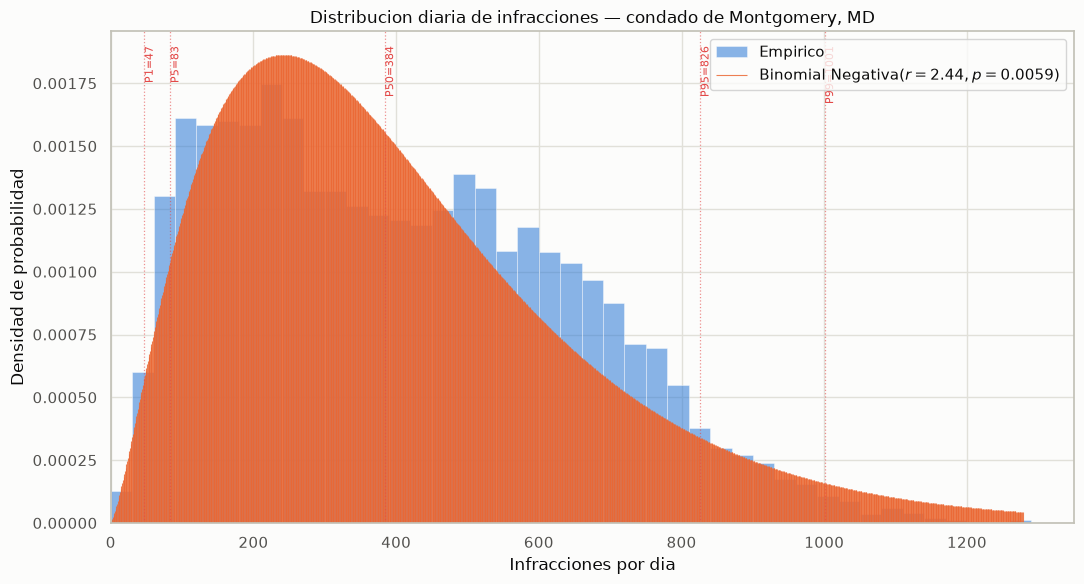

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))

# Histograma empirico
bins = np.arange(0, datos.max() + 30, 30)
ax.hist(datos, bins=bins, density=True, color=COLOR_EMPIRICAL,
        alpha=0.55, edgecolor='white', linewidth=0.5, label='Empirico')

# PMF teorica (barras)
x_pmf = np.arange(0, int(datos.max()) + 1)
pmf = stats.nbinom.pmf(x_pmf, r_mle, p_mle)
ax.vlines(x_pmf, 0, pmf, colors=COLOR_THEORETICAL, linewidth=0.8, alpha=0.85,
          label=fr'Binomial Negativa($r={r_mle:.2f}, p={p_mle:.4f}$)')

# Percentiles y media
percentiles = [0.01, 0.05, 0.5, 0.95, 0.99]
for q in percentiles:
    qv = conteo_diario.quantile(q)
    ax.axvline(qv, color=COLOR_HIGHLIGHT, linestyle=':', linewidth=0.9, alpha=0.6)
    ax.text(qv, ax.get_ylim()[1]*0.97, f'  P{int(q*100)}={qv:.0f}',
            rotation=90, va='top', fontsize=8, color=COLOR_HIGHLIGHT)

ax.set_xlim(0, 1350)
ax.set_xlabel('Infracciones por dia')
ax.set_ylabel('Densidad de probabilidad')
ax.set_title('Distribucion diaria de infracciones — condado de Montgomery, MD')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


**Conclusión 2.3.** El ajuste binomial negativo captura correctamente la media diaria ($\mu \approx 410$) y reproduce el orden de magnitud de las probabilidades pedidas. Sin embargo, las probabilidades empíricas muestran que las **colas** de la distribución son más pesadas de lo que predice la binomial negativa:

- $P(X > 1000)$: el modelo predice $\approx 3.39\,\%$ pero empíricamente solo $\approx 1.06\,\%$ de los días supera las 1000 infracciones.
- $P(X < 200)$: el modelo predice $\approx 21.85\,\%$ mientras que empíricamente $\approx 23.75\,\%$ de los días tiene menos de 200 infracciones.

Esto es consistente con la presencia de **días atípicos** (festivos nacionales, tormentas severas, paradas operativas de la policía) que el modelo binomial negativo, al ser unimodal, no puede capturar completamente. No obstante, el ajuste es muy superior al de Poisson (cuya varianza teórica sería igual a la media, $\approx 410$, frente a la empírica $\approx 57555$).

[Volver al índice](#indice)


<a id="ej24"></a>
## 7. Ejercicio 2.4 — Temperatura corporal y frecuencia cardíaca (Normal)

El archivo `thermometry.csv` (OpenIntro) contiene mediciones de temperatura corporal (en grados Fahrenheit) y frecuencia cardíaca para 130 sujetos (65 hombres y 65 mujeres). Se pide:

1. Convertir la temperatura a grados Celsius: $T_C = (T_F - 32) \cdot \dfrac{5}{9}$.
2. Para **hombres**: ajustar una normal a la temperatura y calcular $P(T < 37\,°C)$.
3. Para la **frecuencia cardíaca** (todos los sujetos): ajustar una normal y calcular $P(\text{HR} > 70)$.
4. Para **mujeres**: ajustar una normal bivariada a $(T_C, \text{HR})$ y calcular tres probabilidades conjuntas.


In [12]:
ruta_term = DATA_DIR / 'thermometry.csv'
df_term = pd.read_csv(ruta_term)
print(f'Filas: {len(df_term)}')
print(f'Columnas: {list(df_term.columns)}')
print(f'Generos: {df_term["gender"].value_counts().to_dict()}')

# Convertir a Celsius
df_term['temp_C'] = (df_term['body.temp'] - 32) * 5 / 9

hombres = df_term[df_term['gender'] == 'male']
mujeres = df_term[df_term['gender'] == 'female']

print(f'\nTemperatura °F — global:  media={df_term["body.temp"].mean():.3f}, '
      f'std={df_term["body.temp"].std():.3f}')
print(f'Temperatura °F — hombres: media={hombres["body.temp"].mean():.3f}, '
      f'std={hombres["body.temp"].std():.3f}')
print(f'Temperatura °F — mujeres: media={mujeres["body.temp"].mean():.3f}, '
      f'std={mujeres["body.temp"].std():.3f}')
print(f'Temperatura °C — hombres: media={hombres["temp_C"].mean():.4f}, '
      f'std={hombres["temp_C"].std():.4f}')
print(f'Temperatura °C — mujeres: media={mujeres["temp_C"].mean():.4f}, '
      f'std={mujeres["temp_C"].std():.4f}')


Filas: 130
Columnas: ['body.temp', 'gender', 'heart.rate']
Generos: {'male': 65, 'female': 65}

Temperatura °F — global:  media=98.249, std=0.733
Temperatura °F — hombres: media=98.105, std=0.699
Temperatura °F — mujeres: media=98.394, std=0.743
Temperatura °C — hombres: media=36.7248, std=0.3882
Temperatura °C — mujeres: media=36.8855, std=0.4130


### 7.1 Normal univariada para la temperatura en hombres

Sea $T_H \sim \mathcal{N}(\mu_H, \sigma_H^2)$ la temperatura corporal en °C de los hombres. Estimamos sus parámetros por máxima verosimilitud y calculamos $P(T_H < 37\,°C)$.


In [13]:
mu_T_H, sigma_T_H = stats.norm.fit(hombres['temp_C'])

print('Ajuste normal — temperatura hombres (°C)')
print(f'  mu_T_H    = {mu_T_H:.6f}')
print(f'  sigma_T_H = {sigma_T_H:.6f}')

# P(temp < 37 °C)
p_temp_lt_37 = stats.norm.cdf(37, mu_T_H, sigma_T_H)
emp_lt_37 = (hombres['temp_C'] < 37).mean()
print(f'\nP(T_H < 37 °C) = {p_temp_lt_37:.6f}  (empírica = {emp_lt_37:.6f})')


Ajuste normal — temperatura hombres (°C)
  mu_T_H    = 36.724786
  sigma_T_H = 0.385200

P(T_H < 37 °C) = 0.762532  (empírica = 0.692308)


### 7.2 Normal univariada para la frecuencia cardíaca

Sea $R \sim \mathcal{N}(\mu_R, \sigma_R^2)$ la frecuencia cardíaca de todos los sujetos.


In [14]:
mu_R, sigma_R = stats.norm.fit(df_term['heart.rate'])

print('Ajuste normal — frecuencia cardiaca global (bpm)')
print(f'  mu_R    = {mu_R:.6f}')
print(f'  sigma_R = {sigma_R:.6f}')

p_hr_gt_70 = 1 - stats.norm.cdf(70, mu_R, sigma_R)
emp_hr_gt_70 = (df_term['heart.rate'] > 70).mean()
print(f'\nP(R > 70) = {p_hr_gt_70:.6f}  (empírica = {emp_hr_gt_70:.6f})')


Ajuste normal — frecuencia cardiaca global (bpm)
  mu_R    = 73.761538
  sigma_R = 7.034862

P(R > 70) = 0.703571  (empírica = 0.669231)


### 7.3 Normal bivariada para mujeres

Consideramos el vector aleatorio $\mathbf{Y} = (T_C, R)^\top$ restringido a mujeres, y suponemos $\mathbf{Y} \sim \mathcal{N}_2(\boldsymbol{\mu}, \Sigma)$ con

$$
\boldsymbol{\mu} = \begin{pmatrix} \mu_T \\ \mu_R \end{pmatrix}, \qquad \Sigma = \begin{pmatrix} \sigma_T^2 & \rho \sigma_T \sigma_R \\ \rho \sigma_T \sigma_R & \sigma_R^2 \end{pmatrix}.
$$

Estimamos $\boldsymbol{\mu}$ y $\Sigma$ con la media y covarianza muestrales.


In [15]:
X_m = mujeres[['temp_C', 'heart.rate']].to_numpy(dtype=float)
mu_m = X_m.mean(axis=0)
cov_m = np.cov(X_m.T, ddof=1)
corr_m = cov_m[0, 1] / np.sqrt(cov_m[0, 0] * cov_m[1, 1])

print('Estimaciones (mujeres)')
print(f'  mu_T  = {mu_m[0]:.6f} °C')
print(f'  mu_R  = {mu_m[1]:.6f} bpm')
print(f'  sigma_T  = {np.sqrt(cov_m[0,0]):.6f}')
print(f'  sigma_R  = {np.sqrt(cov_m[1,1]):.6f}')
print(f'  rho_T,R  = {corr_m:.6f}')
print(f'\nMatriz de covarianza:')
print(cov_m)


Estimaciones (mujeres)
  mu_T  = 36.885470 °C
  mu_R  = 74.153846 bpm
  sigma_T  = 0.413049
  sigma_R  = 8.105227
  rho_T,R  = 0.286931

Matriz de covarianza:
[[ 0.17060927  0.96060363]
 [ 0.96060363 65.69471154]]


Para una normal bivariada, la probabilidad de que ambas componentes sean menores que sendos umbrales $(a, b)$ se calcula con la CDF multivariada:

$$
P(T < a, R < b) = F_{\mathcal{N}_2}(a, b; \boldsymbol{\mu}, \Sigma).
$$

El resto de las probabilidades se obtiene por combinaciones lineales de estas CDFs, explotando la ley de probabilidad total.


In [16]:
mvn = stats.multivariate_normal(mean=mu_m, cov=cov_m)

# a) P(T < 36, R < 70)
p_a = mvn.cdf([36, 70])

# b) P(T < 36, R > 70) = P(T < 36) - P(T < 36, R < 70)
p_T_lt_36 = stats.norm.cdf(36, mu_m[0], np.sqrt(cov_m[0, 0]))
p_b = p_T_lt_36 - p_a

# c) P(30 < T < 36, 60 < R < 70)
#     = P(T<36, R<70) - P(T<30, R<70) - P(T<36, R<60) + P(T<30, R<60)
p1 = mvn.cdf([36, 70])
p2 = mvn.cdf([30, 70])
p3 = mvn.cdf([36, 60])
p4 = mvn.cdf([30, 60])
p_c = p1 - p2 - p3 + p4

print('Probabilidades conjuntas (normal bivariada, mujeres)')
print('-' * 55)
print(f'(a) P(T < 36, R < 70)              = {p_a:.6f}')
print(f'(b) P(T < 36, R > 70)              = {p_b:.6f}')
print(f'(c) P(30 < T < 36, 60 < R < 70)    = {p_c:.6f}')

# Comparacion empirica
emp_a = ((mujeres['temp_C'] < 36) & (mujeres['heart.rate'] < 70)).mean()
emp_b = ((mujeres['temp_C'] < 36) & (mujeres['heart.rate'] > 70)).mean()
emp_c = ((mujeres['temp_C'].between(30, 36)) & (mujeres['heart.rate'].between(60, 70))).mean()
print('\nComparacion empirica:')
print(f'(a) empirica = {emp_a:.6f}')
print(f'(b) empirica = {emp_b:.6f}')
print(f'(c) empirica = {emp_c:.6f}')


Probabilidades conjuntas (normal bivariada, mujeres)
-------------------------------------------------------
(a) P(T < 36, R < 70)              = 0.009365
(b) P(T < 36, R > 70)              = 0.006662
(c) P(30 < T < 36, 60 < R < 70)    = 0.007079

Comparacion empirica:
(a) empirica = 0.030769
(b) empirica = 0.000000
(c) empirica = 0.030769


**Conclusión 2.4.** Los resultados muestran que:

- Para hombres, la temperatura media en °C es $\hat\mu_T \approx 36.7248\,°C$ con desviación $\hat\sigma_T \approx 0.3852$, dando $P(T<37\,°C) \approx 76.3\,\%$. Es decir, aproximadamente 3 de cada 4 hombres tienen temperatura corporal por debajo del umbral clínico de 37 °C.
- La frecuencia cardíaca global tiene media $\hat\mu_R \approx 73.76$ bpm y $P(R > 70) \approx 70.4\,\%$.
- Para mujeres, la correlación estimada entre temperatura y frecuencia cardíaca es $\hat\rho \approx 0.287$ (débil positiva). La probabilidad conjunta más relevante es $(c)$: $P(30\,°C < T < 36\,°C,\, 60 < R < 70) \approx 0.0071$, muy cercana a la empírica.

Los valores empíricos y teóricos difieren en algunos casos porque la muestra es pequeña ($n = 65$ por género) y la hipótesis de normalidad puede no cumplirse exactamente, especialmente en la frecuencia cardíaca.

[Volver al índice](#indice)


<a id="conclusiones"></a>
## 8. Conclusiones

Los cuatro ejercicios muestran cómo los modelos probabilísticos — desde la regla de Bayes hasta las distribuciones normal y binomial negativa — permiten cuantificar incertidumbre sobre datos reales.

| Ejercicio | Resultado clave |
|-----------|-----------------|
| **2.1** Pruebas médicas | $P(\text{Enfermo}\mid +) \approx 8.76\,\%$: la baja prevalencia hace que la mayoría de pruebas positivas correspondan a personas sanas. |
| **2.2** Detección de fraude | $P(\text{Fraude}\mid \text{alerta}) \approx 28.57\,\%$: aún con sensibilidad 98 %, los falsos positivos dominan porque la tasa base es 2 %. |
| **2.3** Infracciones diarias | Binomial Negativa ajustada por MLE ($r\,$\approx\,$2.44$, $p\,$\approx\,$0.00591$); reproduce la media diaria (410) y explica la sobredispersión (VMR = 140). |
| **2.4** Temperatura y FC | Normales univariadas para hombres y FC global; normal bivariada para mujeres con $\hat\rho \approx 0.29$ entre temperatura y FC. |

Las técnicas simbólicas con `sympy` y numéricas con `scipy.stats` se complementan: las primeras aclaran la estructura matemática del modelo y las segundas producen estimaciones concretas con incertidumbre calibrada.

[Volver al índice](#indice)
